# Domain shift / degradation trend analysis

Questa analisi non usa il modello ST-GNN e non richiede training. Misura se la produzione reale degli impianti cala nel tempo rispetto a una baseline meteo/PVGIS.

- `pr_pvgis = ENERGIA reale / (kWp * PVGIS_POA)`: performance normalizzata rispetto a quanto ci si aspetta dato l'irraggiamento.
- Il degrado/perdita viene stimato con il trend mensile di `pr_pvgis` per singolo impianto.
- `pr_plant_z = (pr_pvgis - media_PR_impianto) / std_PR_impianto`: controllo standardizzato rispetto alla variabilita' dello stesso impianto.


In [17]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..').resolve()
OUT = ROOT / 'outputs' / 'domain_shift_trend'
OUT

PosixPath('/home/apedalino/physiq_pv/outputs/domain_shift_trend')

## Run dello script

Esegui questa cella per rigenerare CSV, summary e grafici. Se hai gia' generato gli output, puoi saltarla e caricare direttamente le celle successive.

In [18]:
cmd = [
    sys.executable,
    str(ROOT / 'scripts' / 'analyze_domain_shift_trend.py'),
    '--out-dir', str(OUT),
    '--kwp-mode', 'real-only',
    '--plausible-pr-min', '0.2',
    '--plausible-pr-max', '2.0',
]
env = os.environ.copy()
env['PYTHONPATH'] = str(ROOT) + os.pathsep + env.get('PYTHONPATH', '')

print(' '.join(cmd))
res = subprocess.run(cmd, cwd=ROOT, env=env, text=True, capture_output=True)
print(res.stdout)
if res.returncode != 0:
    print(res.stderr)
    raise RuntimeError(f'Script failed with exit code {res.returncode}')

/home/apedalino/physiq_pv/.venv/bin/python /home/apedalino/physiq_pv/scripts/analyze_domain_shift_trend.py --out-dir /home/apedalino/physiq_pv/outputs/domain_shift_trend --kwp-mode real-only --plausible-pr-min 0.2 --plausible-pr-max 2.0
  Found 1116 Sentinel files for year 2019
  Loading 1116 UPN plants...
  Unique timestamps across all plants: 5743
  Stacked: 1116 plants x 5743 timesteps (aligned to common time grid)
  Dataset: 1116 plants x 5743 hours
  Matching 1116 plants to PVGIS grid (1149 locations)...
  Time alignment: Sentinel 5743 hours, PVGIS 8760 hours
  Merged weather variables: temperature_2m, solar_irradiance_poa, wind_speed_10m

=== DOMAIN-SHIFT / DEGRADATION TREND REPORT ===
Output directory: /home/apedalino/physiq_pv/outputs/domain_shift_trend
Plants: 1116  hours: 5743
kWp real/proxy: 94/1022
kWp mode: real-only
plausible PR filter: [0.2, 2.0]  excluded=0

Fleet trends:
  fleet_weighted_pr_pvgis_monthly: slope/year=+0.0194, rel/year=+2.25%, p=0.87, decreasing=False
  

## Summary numerico

In [19]:
with open(OUT / 'summary.json', encoding='utf-8') as f:
    summary = json.load(f)

summary

{'period_start': '2019-03-01',
 'period_end': '2019-12-31',
 'n_plants': 1116,
 'n_hours': 5743,
 'n_real_kwp': 94,
 'n_proxy_kwp': 1022,
 'daytime_poa_threshold_wm2': 50.0,
 'reference_pr': 1.0,
 'kwp_mode': 'real-only',
 'plausible_pr_min': 0.2,
 'plausible_pr_max': 2.0,
 'n_excluded_implausible_pr': 0,
 'min_months': 4,
 'alpha': 0.05,
 'fleet_trends': [{'metric': 'fleet_weighted_pr_pvgis_monthly',
   'plant': 'fleet',
   'plant_id': 'fleet',
   'n_points': 8,
   'start': '2019-03-31',
   'end': '2019-12-31',
   'mean_value': 0.8644268992079749,
   'first_value': 0.9883268645054365,
   'last_value': 0.9585674794526177,
   'slope_per_month': 0.001620183945610012,
   'slope_per_year': 0.019442207347320144,
   'relative_change_pct_per_year': 2.249144186180917,
   'p_value': 0.8697146025722886,
   'kendall_tau': 0.21428571428571427,
   'kendall_p_value': 0.5484126984126985,
   'decreasing': False},
  {'metric': 'fleet_median_pr_pvgis_monthly',
   'plant': 'fleet',
   'plant_id': 'fleet'

In [20]:
fleet_trends = pd.read_csv(OUT / 'fleet_trend_summary.csv')
plant_trends = pd.read_csv(OUT / 'plant_trend_summary.csv')
fleet_monthly = pd.read_csv(OUT / 'fleet_monthly_performance.csv', parse_dates=['date'])
plant_monthly = pd.read_csv(OUT / 'plant_monthly_performance.csv', parse_dates=['date'])

fleet_trends

,metric,plant,plant_id,n_points,start,end,mean_value,first_value,last_value,slope_per_month,slope_per_year,relative_change_pct_per_year,p_value,kendall_tau,kendall_p_value,decreasing
0,fleet_weighted_pr_pvgis_monthly,fleet,fleet,8,2019-03-31,2019-12-31,0.864427,0.988327,0.958567,0.001620,0.019442,2.249144,0.869715,0.214286,0.548413,False
1,fleet_median_pr_pvgis_monthly,fleet,fleet,8,2019-03-31,2019-12-31,0.799071,0.863948,0.901022,0.002653,0.031837,3.984243,0.723619,0.142857,0.719544,False


## Grafici generati dallo script

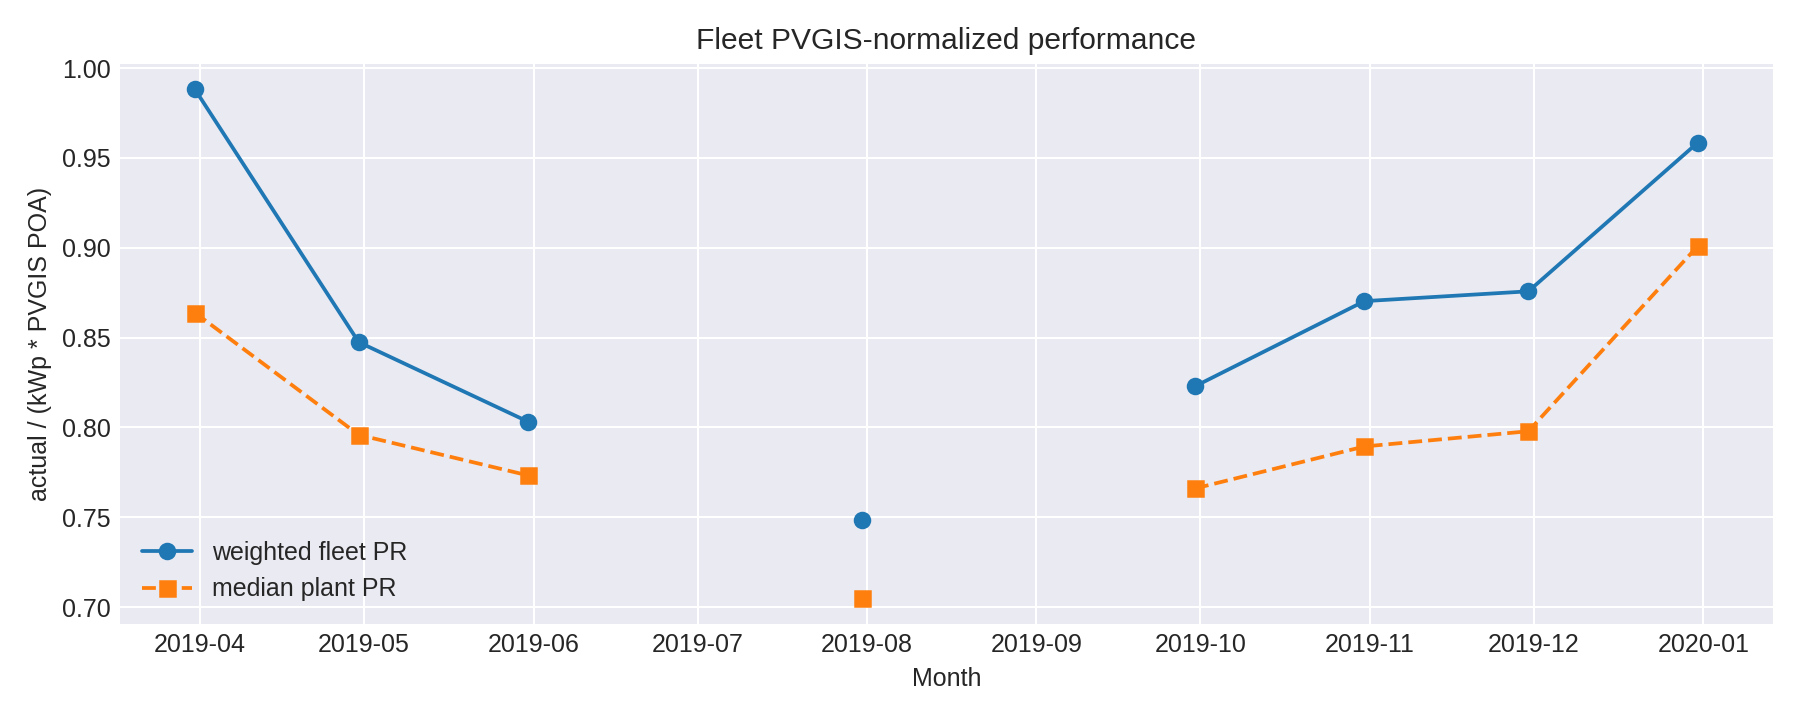

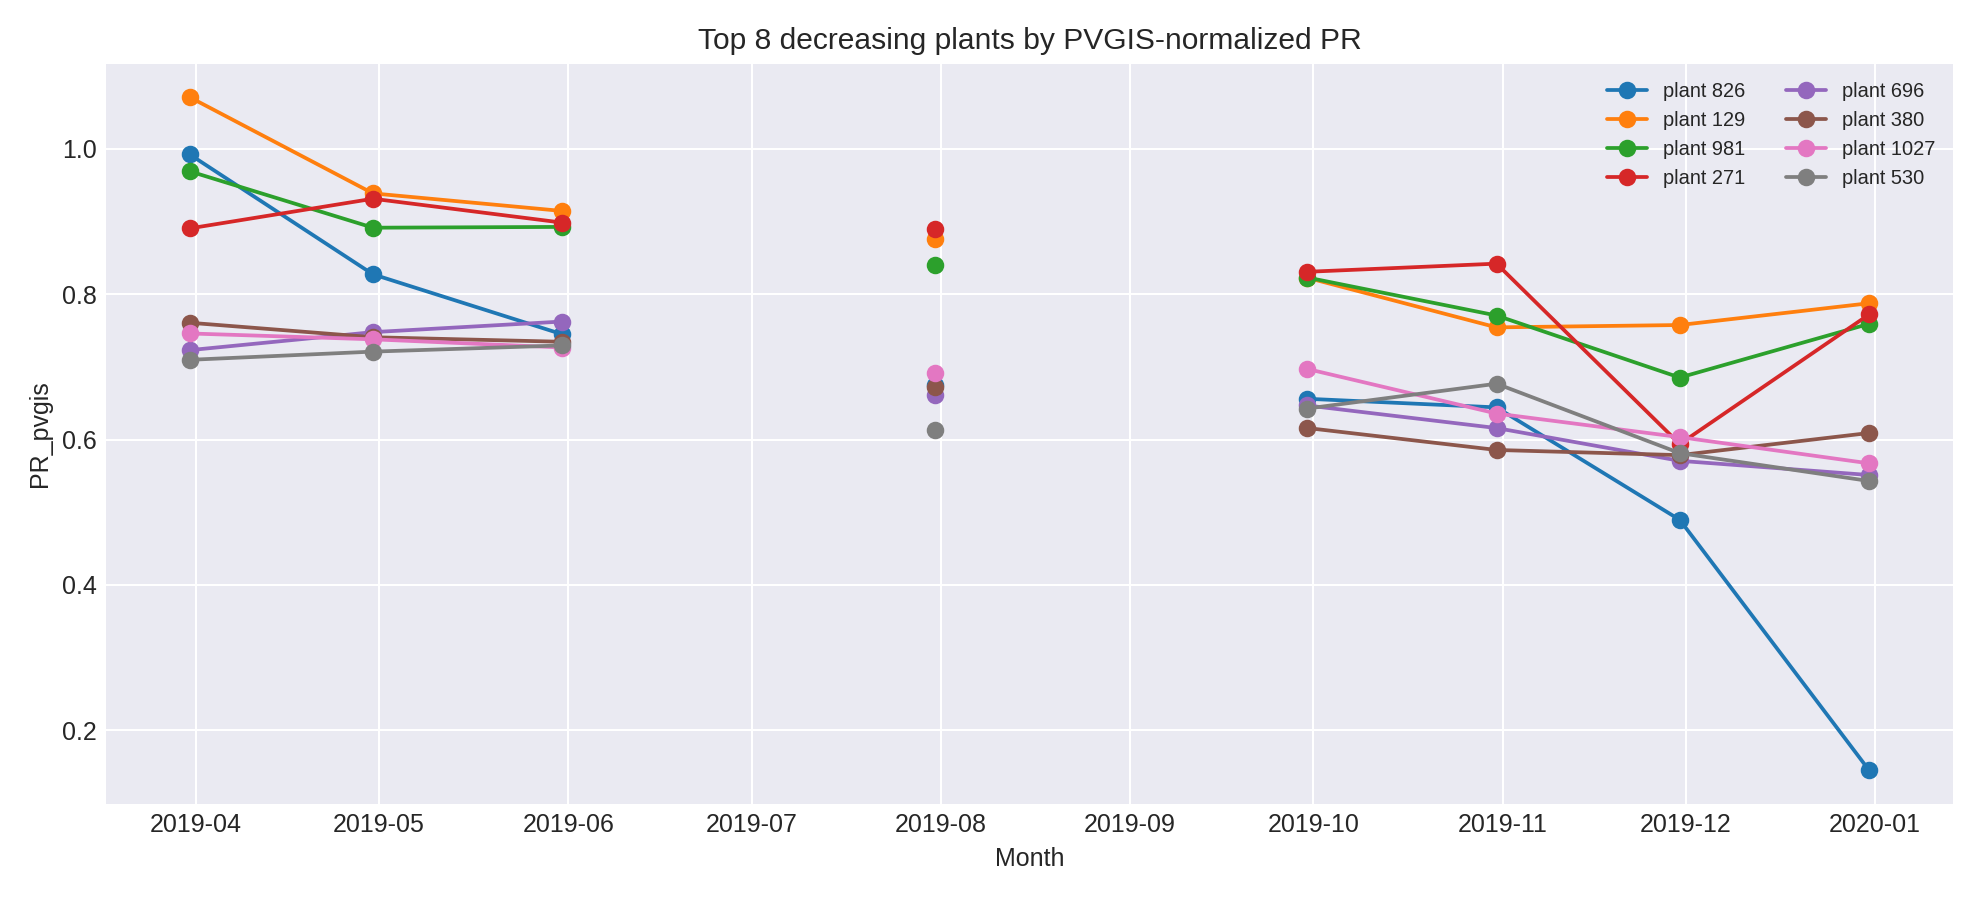

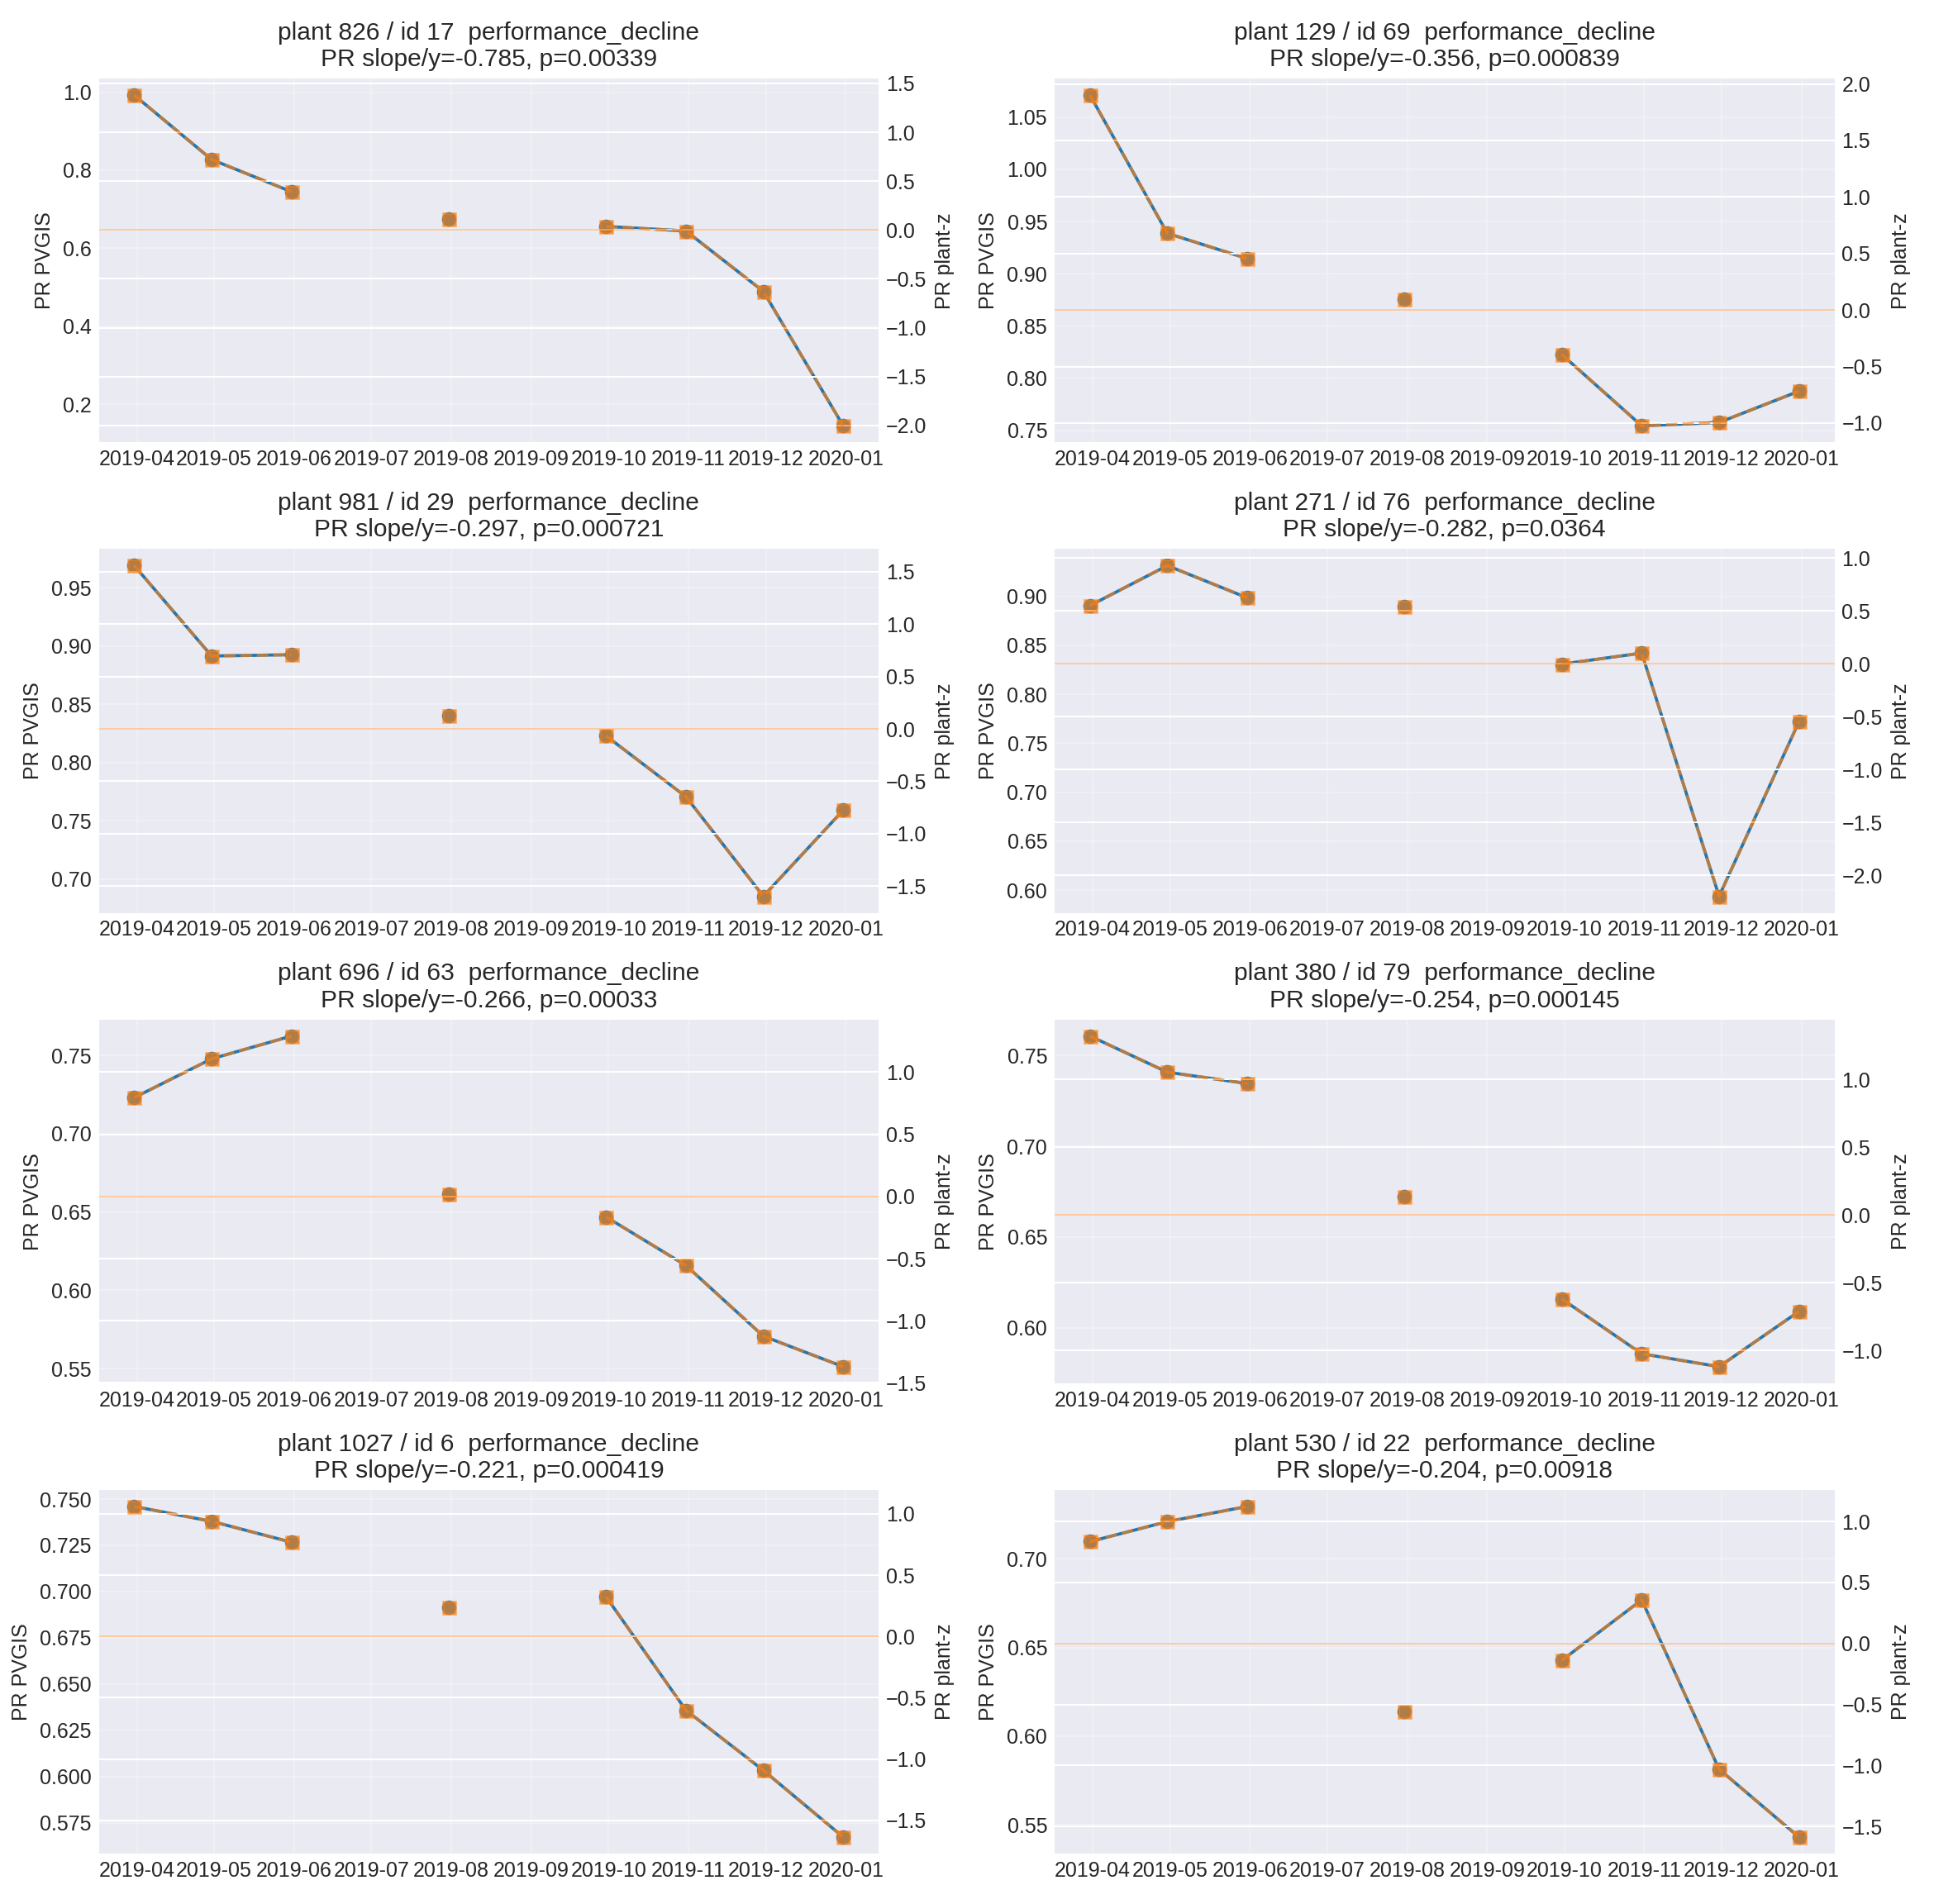

In [21]:
for name in ['fleet_pvgis_pr_trend.png', 'top_decreasing_plants_pvgis_pr.png', 'individual_candidate_plant_trends.png']:
    path = OUT / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Missing: {path}')

## Impianti con trend decrescente piu' forte

In [22]:
cols = [
    'metric', 'plant', 'plant_id', 'n_points', 'mean_value',
    'slope_per_year', 'relative_change_pct_per_year', 'p_value',
    'kendall_tau', 'decreasing'
]

pr_trends = plant_trends[plant_trends['metric'] == 'pr_pvgis_monthly'].copy()
pr_trends.sort_values('slope_per_year')[cols].head(20)

,metric,plant,plant_id,n_points,mean_value,slope_per_year,relative_change_pct_per_year,p_value,kendall_tau,decreasing
142,pr_pvgis_monthly,826,17,8,0.646808,-0.785016,-121.367671,0.003390,-1.000000,True
16,pr_pvgis_monthly,129,69,8,0.865318,-0.355875,-41.126495,0.000839,-0.785714,True
162,pr_pvgis_monthly,981,29,8,0.828977,-0.296909,-35.816334,0.000721,-0.857143,True
30,pr_pvgis_monthly,271,76,8,0.831120,-0.281841,-33.911036,0.036380,-0.714286,True
96,pr_pvgis_monthly,696,63,8,0.659940,-0.266330,-40.356648,0.000330,-0.785714,True
52,pr_pvgis_monthly,380,79,8,0.662210,-0.253919,-38.344165,0.000145,-0.857143,True
170,pr_pvgis_monthly,1027,6,8,0.675736,-0.221212,-32.736404,0.000419,-0.928571,True
76,pr_pvgis_monthly,530,22,8,0.652246,-0.204339,-31.328531,0.009180,-0.571429,True
104,pr_pvgis_monthly,720,86,8,0.658381,-0.201556,-30.613846,0.002911,-0.642857,True
122,pr_pvgis_monthly,780,21,8,0.715503,-0.201434,-28.152752,0.019576,-0.642857,True


## Andamento fleet mensile

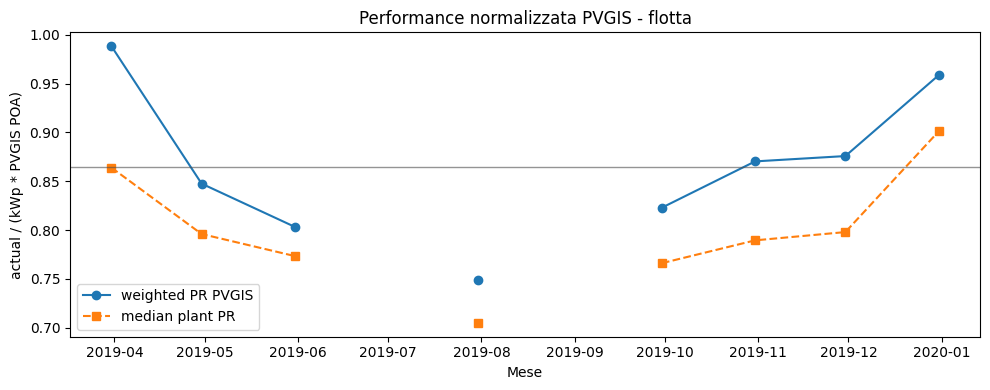

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fleet_monthly['date'], fleet_monthly['weighted_pr_pvgis'], 'o-', label='weighted PR PVGIS')
ax.plot(fleet_monthly['date'], fleet_monthly['median_pr_pvgis'], 's--', label='median plant PR')
ax.axhline(fleet_monthly['weighted_pr_pvgis'].mean(), color='0.3', linewidth=1, alpha=0.6)
ax.set_xlabel('Mese')
ax.set_ylabel('actual / (kWp * PVGIS POA)')
ax.set_title('Performance normalizzata PVGIS - flotta')
ax.legend()
plt.tight_layout()

## Lettura per la tesi

Un trend negativo di `pr_pvgis` indica che, a parita' di riferimento meteo/PVGIS e capacita' stimata o reale, la produzione cala nel tempo. Questo e' il segnale piu' vicino a soiling, degrado sistemico o domain shift temporale dell'impianto.

`pr_plant_z` esprime lo stesso andamento in deviazioni standard rispetto alla media dello stesso impianto. Non e' una vera correzione stagionale mese-calendario con un solo anno, ma aiuta a capire se il calo e' grande rispetto alla variabilita' dell'impianto.

Con un solo anno il risultato resta esplorativo: il trend puo' includere degrado moduli, soiling, disponibilita' impianto, curtailment, clipping o problemi di misura.

## Report compatto da mandare per controllo

Esegui questa cella e manda l'output testuale completo. Contiene i numeri necessari per controllare se il trend e' interpretabile come degrado/domain shift o se e' probabilmente stagionalita'/artefatto.

In [24]:
def _compact_report(out_dir: Path, top_n: int = 20):
    with open(out_dir / 'summary.json', encoding='utf-8') as f:
        summary = json.load(f)

    fleet_trends = pd.read_csv(out_dir / 'fleet_trend_summary.csv')
    plant_trends = pd.read_csv(out_dir / 'plant_trend_summary.csv')
    fleet_monthly = pd.read_csv(out_dir / 'fleet_monthly_performance.csv')
    plant_monthly = pd.read_csv(out_dir / 'plant_monthly_performance.csv')
    candidate_path = out_dir / 'plant_candidate_summary.csv'
    candidate_summary = pd.read_csv(candidate_path) if candidate_path.exists() else pd.DataFrame()
    def _safe_read_csv(path: Path) -> pd.DataFrame:
        if not path.exists() or path.stat().st_size == 0:
            return pd.DataFrame()
        try:
            return pd.read_csv(path)
        except pd.errors.EmptyDataError:
            return pd.DataFrame()

    excluded_path = out_dir / 'excluded_implausible_pr.csv'
    excluded = _safe_read_csv(excluded_path)
    diag_path = out_dir / 'excluded_implausible_pr_diagnostics.csv'
    excluded_diag = _safe_read_csv(diag_path)

    pr = plant_trends[plant_trends['metric'] == 'pr_pvgis_monthly'].copy()
    plant_z = plant_trends[plant_trends['metric'] == 'pr_plant_z_monthly'].copy()
    pr_top = pr.sort_values('slope_per_year').head(top_n)
    plant_z_top = plant_z.sort_values('slope_per_year').head(top_n) if not plant_z.empty else plant_z

    cols = [
        'plant', 'plant_id', 'n_points', 'mean_value', 'first_value', 'last_value',
        'slope_per_year', 'relative_change_pct_per_year', 'p_value',
        'kendall_tau', 'kendall_p_value', 'decreasing'
    ]

    print('=== SUMMARY.JSON ===')
    print(json.dumps(summary, indent=2))

    print('\n=== FLEET TREND SUMMARY ===')
    print(fleet_trends.to_string(index=False))

    print('\n=== FLEET MONTHLY PERFORMANCE ===')
    fm_cols = ['date', 'n_plants', 'actual_kwh', 'pvgis_expected_kwh', 'weighted_pr_pvgis', 'median_pr_pvgis']
    print(fleet_monthly[fm_cols].to_string(index=False))

    print(f'\n=== TOP {top_n} DECREASING PLANTS: PR_PVGIS ===')
    print(pr_top[cols].to_string(index=False))

    print(f'\n=== TOP {top_n} DECREASING PLANTS: PR_PLANT_Z ===')
    if plant_z_top.empty:
        print('missing pr_plant_z_monthly; rerun analyze_domain_shift_trend.py')
    else:
        print(plant_z_top[cols].to_string(index=False))

    print(f'\n=== TOP {top_n} LOCAL DECLINE CANDIDATES ===')
    if candidate_summary.empty:
        print('missing plant_candidate_summary.csv')
    else:
        cand_cols = [
            'candidate_class', 'plant', 'plant_id', 'upn', 'valid_months',
            'pr_mean', 'pr_first', 'pr_last', 'first_to_last_pct',
            'pr_slope_per_year', 'pr_p_value', 'plant_pr_mean', 'plant_pr_std',
            'plant_z_slope_per_year', 'plant_z_p_value', 'peak_to_last_pct',
            'statistical_note'
        ]
        existing = [c for c in cand_cols if c in candidate_summary.columns]
        print(candidate_summary[existing].head(top_n).to_string(index=False))

    print('\n=== DATA COVERAGE / SOURCES ===')
    print('plant_monthly rows:', len(plant_monthly))
    print('plants in monthly table:', plant_monthly['plant'].nunique())
    print('kwp_source counts:')
    print(plant_monthly[['plant', 'kwp_source']].drop_duplicates()['kwp_source'].value_counts().to_string())
    print('valid monthly points per plant:')
    print(plant_monthly.groupby('plant')['pr_pvgis'].count().describe().to_string())
    print('\n=== EXCLUDED IMPLAUSIBLE PR PLANTS ===')
    if excluded.empty:
        print('none')
    else:
        ex_cols = ['plant', 'plant_id', 'mean_pr_pvgis', 'median_pr_pvgis', 'min_pr_pvgis', 'max_pr_pvgis', 'n_valid_months', 'kwp_used', 'kwp_source']
        print(excluded.sort_values('mean_pr_pvgis', ascending=False)[ex_cols].head(40).to_string(index=False))

    print('\n=== WHY PR IS IMPLAUSIBLE: COMPONENT DIAGNOSTICS ===')
    if excluded_diag.empty:
        print('none')
    else:
        diag_cols = [
            'plant', 'plant_id', 'upn', 'Codice UP', 'Codice Censimp Impianto',
            'mean_pr_pvgis', 'kwp_used', 'actual_sum_kwh',
            'expected_sum_kwh_pr1', 'actual_over_expected_sum', 'energy_p99',
            'energy_p99_over_kwp', 'energy_max', 'energy_max_over_kwp',
            'poa_kwm2_p99', 'poa_kwm2_max', 'suggested_energy_multiplier',
            'mean_pr_after_suggested_multiplier', 'diagnostic_flags'
        ]
        existing = [c for c in diag_cols if c in excluded_diag.columns]
        print(excluded_diag[existing].head(40).to_string(index=False))

_compact_report(OUT, top_n=20)

=== SUMMARY.JSON ===
{
  "period_start": "2019-03-01",
  "period_end": "2019-12-31",
  "n_plants": 1116,
  "n_hours": 5743,
  "n_real_kwp": 94,
  "n_proxy_kwp": 1022,
  "daytime_poa_threshold_wm2": 50.0,
  "reference_pr": 1.0,
  "kwp_mode": "real-only",
  "plausible_pr_min": 0.2,
  "plausible_pr_max": 2.0,
  "n_excluded_implausible_pr": 0,
  "min_months": 4,
  "alpha": 0.05,
  "fleet_trends": [
    {
      "metric": "fleet_weighted_pr_pvgis_monthly",
      "plant": "fleet",
      "plant_id": "fleet",
      "n_points": 8,
      "start": "2019-03-31",
      "end": "2019-12-31",
      "mean_value": 0.8644268992079749,
      "first_value": 0.9883268645054365,
      "last_value": 0.9585674794526177,
      "slope_per_month": 0.001620183945610012,
      "slope_per_year": 0.019442207347320144,
      "relative_change_pct_per_year": 2.249144186180917,
      "p_value": 0.8697146025722886,
      "kendall_tau": 0.21428571428571427,
      "kendall_p_value": 0.5484126984126985,
      "decreasing": fa